# hscredit.core.selectors 特征筛选模块示例

本示例展示 `hscredit.core.selectors` 模块中各种特征筛选器的使用方法。

## 模块概述

该模块提供了多种特征筛选方法，从多个维度评估和筛选特征：

| 类别 | 筛选器 | 说明 |
|------|--------|------|
| **过滤法 - 基础筛选** | `NullSelector` | 移除缺失率过高的特征 |
| | `ModeSelector` | 移除单一值占比过高的特征 |
| | `VarianceSelector` | 移除方差过低的特征 |
| | `CardinalitySelector` | 移除基数过高/过低的特征 |
| | `TypeSelector` | 按数据类型筛选特征 |
| | `RegexSelector` | 按正则表达式筛选特征 |
| **过滤法 - 相关性筛选** | `CorrSelector` | 移除高度相关的特征 |
| | `VIFSelector` | 移除多重共线性特征 |
| **过滤法 - 目标导向筛选** | `IVSelector` | 基于IV值筛选 |
| | `LiftSelector` | 基于Lift值筛选 |
| | `PSISelector` | 基于PSI值筛选 |
| | `Chi2Selector` | 卡方检验筛选 |
| | `FTestSelector` | F检验筛选 |
| | `MutualInfoSelector` | 互信息筛选 |
| **嵌入法 - 特征重要性** | `FeatureImportanceSelector` | 模型特征重要性筛选 |
| | `NullImportanceSelector` | 零重要性特征筛选 |
| | `RFESelector` | 递归特征消除 |
| | `SequentialFeatureSelector` | 序列特征选择 |
| | `StepwiseSelector` | 逐步回归筛选 |
| **高级方法** | `BorutaSelector` | Boruta算法筛选 |

## 1. 环境准备

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# 添加项目路径
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 导入所有筛选器
from hscredit.core.selectors import (
    # 基类
    BaseFeatureSelector,
    SelectionReportCollector,
    CompositeFeatureSelector,
    
    # 过滤法 - 基础筛选
    NullSelector,
    ModeSelector,
    VarianceSelector,
    CardinalitySelector,
    TypeSelector,
    RegexSelector,
    
    # 过滤法 - 相关性筛选
    CorrSelector,
    VIFSelector,
    
    # 过滤法 - 目标导向筛选
    IVSelector,
    LiftSelector,
    PSISelector,
    Chi2Selector,
    FTestSelector,
    MutualInfoSelector,
    
    # 嵌入法
    FeatureImportanceSelector,
    NullImportanceSelector,
    RFESelector,
    SequentialFeatureSelector,
    StepwiseSelector,
    
    # 高级方法
    BorutaSelector,
)

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("特征筛选模块导入成功！")

特征筛选模块导入成功！


## 2. 加载数据

In [2]:
# 加载示例数据
data_path = Path("../utils/hscredit.xlsx")
df = pd.read_excel(data_path)

print(f"数据集形状: {df.shape}")
print(f"\n列名: {df.columns.tolist()}")
print(f"\n数据类型:\n{df.dtypes}")

数据集形状: (22729, 10)

列名: ['MOB1', 'MOB2', '青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单', '放款期数']

数据类型:
MOB1                 int64
MOB2                 int64
青云24               float64
游昆定制分80            float64
百融定制分V9            float64
中智小牛分C3            float64
度小满欺诈因子V6PRO多头版    float64
百行百川分FPV1          float64
设备黑名单              float64
放款期数                 int64
dtype: object


In [3]:
# 准备特征和目标变量
numeric_features = [
    '青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3',
    '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单'
]

X = df[numeric_features].copy()
y = (df['MOB1'] > 0).astype(int)  # MOB1 > 0 作为坏样本

# 处理缺失值
X = X.fillna(X.median())

print(f"特征数据: {X.shape}")
print(f"\n目标变量分布:\n{y.value_counts()}")
print(f"\n坏样本率: {y.mean():.2%}")

特征数据: (22729, 7)

目标变量分布:
MOB1
0    19344
1     3385
Name: count, dtype: int64

坏样本率: 14.89%


## 3. 基础筛选器

### 3.1 缺失率筛选器 (NullSelector)

In [4]:
# 创建含有缺失值的数据用于演示
X_with_null = X.copy()
X_with_null['高缺失特征'] = np.nan  # 100% 缺失
X_with_null['中等缺失特征'] = np.where(np.random.random(len(X)) > 0.3, X['青云24'], np.nan)

# 缺失率筛选器
null_selector = NullSelector(threshold=0.5)  # 剔除缺失率 >= 50% 的特征
null_selector.fit(X_with_null)

print("缺失率筛选结果:")
print("="*60)
print(null_selector.get_scores_df())

缺失率筛选结果:
                特征        得分  状态
7            高缺失特征  1.000000  剔除
8           中等缺失特征  0.300893  选中
0             青云24  0.000000  选中
1          游昆定制分80  0.000000  选中
2          百融定制分V9  0.000000  选中
3          中智小牛分C3  0.000000  选中
4  度小满欺诈因子V6PRO多头版  0.000000  选中
5        百行百川分FPV1  0.000000  选中
6            设备黑名单  0.000000  选中


In [5]:
# 查看筛选报告
report = null_selector.get_selection_report()
print(f"筛选器: {report['筛选器']}")
print(f"阈值: {report['阈值']}")
print(f"输入特征数: {report['输入特征数']}")
print(f"选中特征数: {report['选中特征数']}")
print(f"选中特征: {report['选中特征']}")

筛选器: NullSelector
阈值: 0.5
输入特征数: 9
选中特征数: 8
选中特征: ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单', '中等缺失特征']


### 3.2 方差筛选器 (VarianceSelector)

In [6]:
# 方差筛选器 - 移除低方差特征
variance_selector = VarianceSelector(threshold=0.01)
variance_selector.fit(X)

print("方差筛选结果:")
print("="*60)
print(variance_selector.get_scores_df())

方差筛选结果:
                特征           得分  状态
3          中智小牛分C3  9238.366690  选中
2          百融定制分V9  8050.717573  选中
0             青云24  4327.047110  选中
5        百行百川分FPV1  2285.956067  选中
1          游昆定制分80   182.084302  选中
4  度小满欺诈因子V6PRO多头版     9.726788  选中
6            设备黑名单     1.801259  选中


### 3.3 单一值筛选器 (ModeSelector)

In [7]:
# 创建含有单一值特征的数据
X_with_mode = X.copy()
X_with_mode['常量特征'] = 1  # 100% 为同一值
X_with_mode['近似常量'] = np.where(np.random.random(len(X)) > 0.05, 1, 0)  # 95% 为同一值

# 单一值筛选器
mode_selector = ModeSelector(threshold=0.9)  # 剔除单一值占比 >= 90% 的特征
mode_selector.fit(X_with_mode)

print("单一值筛选结果:")
print("="*60)
print(mode_selector.get_scores_df())

单一值筛选结果:
                特征        得分  状态
7             常量特征  1.000000  剔除
8             近似常量  0.951032  剔除
5        百行百川分FPV1  0.620925  选中
4  度小满欺诈因子V6PRO多头版  0.620001  选中
1          游昆定制分80  0.476132  选中
6            设备黑名单  0.365392  选中
3          中智小牛分C3  0.012627  选中
0             青云24  0.008051  选中
2          百融定制分V9  0.001408  选中


## 4. 相关性筛选器

### 4.1 相关性筛选器 (CorrSelector)

In [8]:
# 创建含有高度相关特征的数据
X_with_corr = X.copy()
X_with_corr['青云24_副本'] = X['青云24'] + np.random.normal(0, 0.1, len(X))  # 高度相关
X_with_corr['青云24_完全相同'] = X['青云24']  # 完全相关

# 相关性筛选器
corr_selector = CorrSelector(threshold=0.8, method='pearson')
corr_selector.fit(X_with_corr)

print("相关性筛选结果:")
print("="*60)
print(corr_selector.get_scores_df())

相关性筛选结果:
                特征   得分  状态
0        青云24_完全相同  1.0  选中
1          青云24_副本  1.0  剔除
2            设备黑名单  1.0  选中
3        百行百川分FPV1  1.0  选中
4  度小满欺诈因子V6PRO多头版  1.0  选中
5          中智小牛分C3  1.0  选中
6          百融定制分V9  1.0  选中
7          游昆定制分80  1.0  选中
8             青云24  1.0  剔除


In [9]:
# 查看相关矩阵
corr_matrix = X_with_corr.corr()
print("相关矩阵 (绝对值):")
print(corr_matrix.abs().round(3))

相关矩阵 (绝对值):
                  青云24  游昆定制分80  百融定制分V9  中智小牛分C3  度小满欺诈因子V6PRO多头版  百行百川分FPV1  \
青云24             1.000    0.335    0.249    0.389            0.174      0.149   
游昆定制分80          0.335    1.000    0.308    0.240            0.193      0.159   
百融定制分V9          0.249    0.308    1.000    0.328            0.290      0.332   
中智小牛分C3          0.389    0.240    0.328    1.000            0.206      0.204   
度小满欺诈因子V6PRO多头版  0.174    0.193    0.290    0.206            1.000      0.418   
百行百川分FPV1        0.149    0.159    0.332    0.204            0.418      1.000   
设备黑名单            0.181    0.236    0.115    0.133            0.068      0.046   
青云24_副本          1.000    0.335    0.249    0.389            0.174      0.149   
青云24_完全相同        1.000    0.335    0.249    0.389            0.174      0.149   

                 设备黑名单  青云24_副本  青云24_完全相同  
青云24             0.181    1.000      1.000  
游昆定制分80          0.236    0.335      0.335  
百融定制分V9          0.115    0.249      0.249

### 4.2 VIF筛选器 (VIFSelector)

In [10]:
# VIF筛选器 - 检测多重共线性
vif_selector = VIFSelector(threshold=4.0)  # VIF > 4 视为存在多重共线性
vif_selector.fit(X_with_corr)

print("VIF筛选结果:")
print("="*60)
print(vif_selector.get_scores_df())

VIF筛选结果:
                特征        得分  状态
1          百融定制分V9  1.310969  选中
2          中智小牛分C3  1.284935  选中
6          青云24_副本  1.284661  选中
4        百行百川分FPV1  1.269919  选中
5            设备黑名单  1.046322  选中
3  度小满欺诈因子V6PRO多头版  1.033238  选中
0          游昆定制分80  1.000000  选中


## 5. 目标导向筛选器

### 5.1 IV值筛选器 (IVSelector)

In [11]:
# IV值筛选器 - 金融风控核心指标
iv_selector = IVSelector(threshold=0.02)  # IV >= 0.02 视为有预测能力
iv_selector.fit(X, y)

print("IV值筛选结果:")
print("="*60)
print(iv_selector.get_iv_interpretation())

IV值筛选结果:
                特征       IV值           预测能力
2          百融定制分V9  1.886607  极强预测能力（可能过拟合）
4  度小满欺诈因子V6PRO多头版  0.601205  极强预测能力（可能过拟合）
3          中智小牛分C3  0.320082          强预测能力
5        百行百川分FPV1  0.249322         中等预测能力
0             青云24  0.206246         中等预测能力
1          游昆定制分80  0.107565         中等预测能力
6            设备黑名单  0.008448          无预测能力


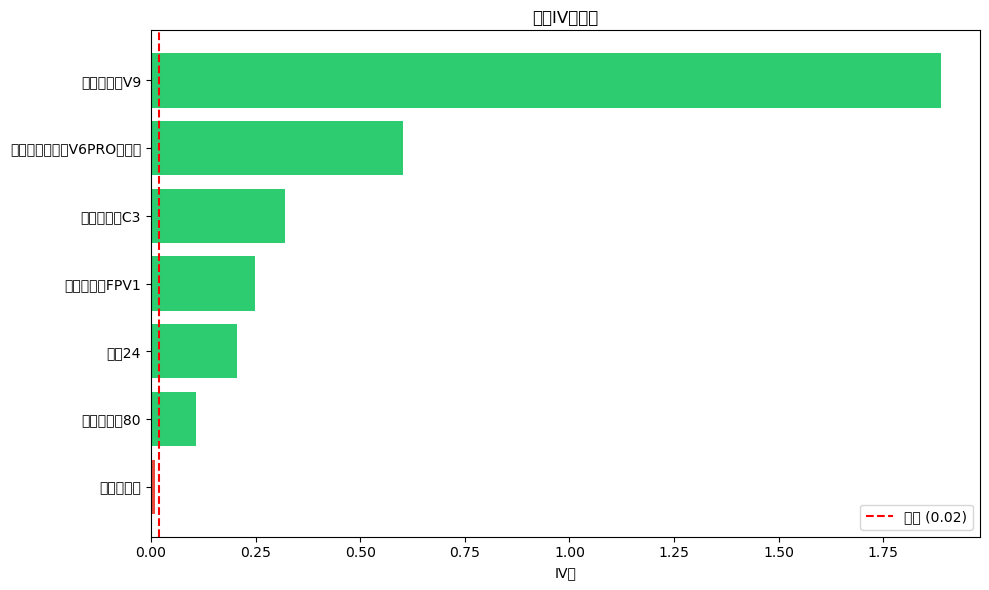

In [12]:
# 可视化IV值
iv_df = iv_selector.get_scores_df()
iv_df = iv_df.sort_values('得分', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if s == '选中' else '#e74c3c' for s in iv_df['状态']]
bars = ax.barh(iv_df['特征'], iv_df['得分'], color=colors)

ax.axvline(x=0.02, color='red', linestyle='--', label='阈值 (0.02)')
ax.set_xlabel('IV值')
ax.set_title('特征IV值分布')
ax.legend()

plt.tight_layout()
plt.show()

### 5.2 卡方检验筛选器 (Chi2Selector)

In [13]:
# 卡方检验筛选器
chi2_selector = Chi2Selector(threshold=0.05)  # p值 < 0.05 视为显著
chi2_selector.fit(X, y)

print("卡方检验筛选结果:")
print("="*60)
print(chi2_selector.get_scores_df())

卡方检验筛选结果:
                特征           得分  状态
2          百融定制分V9  5633.779400  选中
3          中智小牛分C3  4519.040103  选中
5        百行百川分FPV1  3504.084405  选中
0             青云24  1337.771754  选中
1          游昆定制分80    56.754147  选中
4  度小满欺诈因子V6PRO多头版    29.065358  选中
6            设备黑名单     4.103930  选中


### 5.3 F检验筛选器 (FTestSelector)

In [14]:
# F检验筛选器
f_test_selector = FTestSelector(threshold=0.05)  # p值 < 0.05 视为显著
f_test_selector.fit(X, y)

print("F检验筛选结果:")
print("="*60)
print(f_test_selector.get_scores_df())

F检验筛选结果:
                特征          得分  状态
2          百融定制分V9  542.614156  选中
5        百行百川分FPV1  350.895700  选中
3          中智小牛分C3  304.901870  选中
1          游昆定制分80  222.777415  选中
0             青云24  187.186339  选中
4  度小满欺诈因子V6PRO多头版  152.215080  选中
6            设备黑名单    4.315293  选中


### 5.4 互信息筛选器 (MutualInfoSelector)

In [15]:
# 互信息筛选器
mi_selector = MutualInfoSelector(threshold=0.01)
mi_selector.fit(X, y)

print("互信息筛选结果:")
print("="*60)
print(mi_selector.get_scores_df())

互信息筛选结果:
                特征        得分  状态
2          百融定制分V9  0.043689  选中
4  度小满欺诈因子V6PRO多头版  0.017424  选中
5        百行百川分FPV1  0.014533  选中
3          中智小牛分C3  0.011246  选中
1          游昆定制分80  0.008961  剔除
0             青云24  0.007860  剔除
6            设备黑名单  0.000000  剔除


In [16]:
df

sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')


### 5.5 PSI稳定性筛选器 (PSISelector)

In [17]:
# PSI筛选器 - 检测特征分布稳定性
psi_selector = PSISelector(threshold=0.25)  # PSI < 0.25 视为稳定
psi_selector.fit(X, y)

print("PSI筛选结果:")
print("="*60)
print(psi_selector.get_scores_df())

PSI筛选结果:
                特征        得分  状态
0             青云24  0.002840  选中
3          中智小牛分C3  0.002789  选中
1          游昆定制分80  0.002467  选中
2          百融定制分V9  0.002176  选中
6            设备黑名单  0.001007  选中
5        百行百川分FPV1  0.000936  选中
4  度小满欺诈因子V6PRO多头版  0.000398  选中


In [18]:
# PSI值解释
def interpret_psi(psi):
    if psi < 0.1:
        return '稳定性好'
    elif psi < 0.25:
        return '轻微变化，需关注'
    else:
        return '分布变化显著，需处理'

psi_df = psi_selector.get_scores_df()
psi_df['稳定性'] = psi_df['得分'].apply(interpret_psi)
print("\nPSI值解释:")
print(psi_df)


PSI值解释:
                特征        得分  状态   稳定性
0             青云24  0.002840  选中  稳定性好
3          中智小牛分C3  0.002789  选中  稳定性好
1          游昆定制分80  0.002467  选中  稳定性好
2          百融定制分V9  0.002176  选中  稳定性好
6            设备黑名单  0.001007  选中  稳定性好
5        百行百川分FPV1  0.000936  选中  稳定性好
4  度小满欺诈因子V6PRO多头版  0.000398  选中  稳定性好


## 6. 嵌入法筛选器

### 6.1 特征重要性筛选器 (FeatureImportanceSelector)

In [19]:
from sklearn.ensemble import RandomForestClassifier

# 使用随机森林的特征重要性
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
importance_selector = FeatureImportanceSelector(rf, threshold=0.05)
importance_selector.fit(X, y)

print("特征重要性筛选结果:")
print("="*60)
print(importance_selector.get_scores_df())

特征重要性筛选结果:
                特征        得分  状态
2          百融定制分V9  0.258492  选中
3          中智小牛分C3  0.223164  选中
0             青云24  0.217215  选中
5        百行百川分FPV1  0.088175  选中
4  度小满欺诈因子V6PRO多头版  0.083628  选中
1          游昆定制分80  0.071540  选中
6            设备黑名单  0.057786  选中


In [20]:
# 也可以指定保留 top-k 个特征
importance_selector_top5 = FeatureImportanceSelector(rf, threshold=5)  # 保留前5个
importance_selector_top5.fit(X, y)

print("Top-5 特征:")
print(importance_selector_top5.selected_features_)

Top-5 特征:
['度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '青云24', '中智小牛分C3', '百融定制分V9']


### 6.2 RFE筛选器 (RFESelector)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 使用逻辑回归的RFE
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe_selector = RFESelector(estimator=lr, n_features_to_select=5)
rfe_selector.fit(X, y)

print("RFE筛选结果:")
print("="*60)
print(rfe_selector.get_scores_df())

RFE筛选结果:
                特征  得分  状态
0             青云24   3  剔除
3          中智小牛分C3   2  剔除
1          游昆定制分80   1  选中
2          百融定制分V9   1  选中
4  度小满欺诈因子V6PRO多头版   1  选中
5        百行百川分FPV1   1  选中
6            设备黑名单   1  选中


### 6.3 Boruta筛选器 (BorutaSelector)

In [22]:
# Boruta筛选器 - 基于随机森林的特征选择
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
boruta_selector = BorutaSelector(estimator=rf_boruta, max_iter=50, random_state=42)
boruta_selector.fit(X, y)

print("Boruta筛选结果:")
print("="*60)
print(boruta_selector.get_scores_df())

Boruta筛选结果:
                特征        得分  状态
2          百融定制分V9  0.125768  选中
3          中智小牛分C3  0.109216  选中
0             青云24  0.105584  选中
5        百行百川分FPV1  0.053524  剔除
4  度小满欺诈因子V6PRO多头版  0.047540  剔除
1          游昆定制分80  0.043915  剔除
6            设备黑名单  0.034004  剔除


### 6.4 逐步回归筛选器 (StepwiseSelector)

In [23]:
# 逐步回归筛选器 - 基于AIC准则的双向选择
stepwise_selector = StepwiseSelector(
    estimator='logit',      # 逻辑回归
    direction='both',       # 双向选择
    criterion='aic',        # AIC准则
    p_enter=0.05,           # 前向进入阈值
    p_remove=0.05,          # 后向剔除阈值
    verbose=True            # 打印详细过程
)
stepwise_selector.fit(X, y)

print("\n逐步回归筛选结果:")
print("="*60)
print(f"选中特征: {stepwise_selector.selected_features_}")

步骤 1: 添加特征 '百融定制分V9', aic = 18615.2381
步骤 2: 添加特征 '百行百川分FPV1', aic = 18485.3605
步骤 3: 添加特征 '中智小牛分C3', aic = 18389.3873
步骤 4: 添加特征 '游昆定制分80', aic = 18360.3111
步骤 5: 添加特征 '青云24', aic = 18347.0825
步骤 6: 添加特征 '设备黑名单', aic = 18342.0387
前向选择无改善，停止迭代

逐步回归筛选结果:
选中特征: ['百融定制分V9', '百行百川分FPV1', '中智小牛分C3', '游昆定制分80', '青云24', '设备黑名单']


In [24]:
# 查看逐步回归过程历史
print("\n逐步回归过程历史:")
print("="*60)
for record in stepwise_selector.history_[:10]:  # 显示前10步
    action = '添加' if record['action'] in ['add'] else '剔除'
    print(f"步骤{record['step']}: {action}特征 '{record['feature']}'")


逐步回归过程历史:
步骤1: 添加特征 '百融定制分V9'
步骤2: 添加特征 '百行百川分FPV1'
步骤3: 添加特征 '中智小牛分C3'
步骤4: 添加特征 '游昆定制分80'
步骤5: 添加特征 '青云24'
步骤6: 添加特征 '设备黑名单'


In [25]:
# 也可以使用前向选择
stepwise_forward = StepwiseSelector(
    estimator='logit',
    direction='forward',    # 前向选择
    criterion='bic',        # BIC准则
    verbose=False
)
stepwise_forward.fit(X, y)

print("\n前向选择结果:")
print(f"选中特征: {stepwise_forward.selected_features_}")


前向选择结果:
选中特征: ['百融定制分V9', '百行百川分FPV1', '中智小牛分C3', '游昆定制分80', '青云24']


In [26]:
# 或使用后向消除
stepwise_backward = StepwiseSelector(
    estimator='logit',
    direction='backward',   # 后向消除
    criterion='aic',
    verbose=False
)
stepwise_backward.fit(X, y)

print("\n后向消除结果:")
print(f"选中特征: {stepwise_backward.selected_features_}")


后向消除结果:
选中特征: ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '百行百川分FPV1', '设备黑名单']


## 7. 组合筛选器 (CompositeFeatureSelector)

In [38]:
# 创建组合筛选器 - 按顺序执行多个筛选器
composite_selector = CompositeFeatureSelector([
    NullSelector(threshold=0.5),           # 第一步: 剔除高缺失率特征
    VarianceSelector(threshold=0.01),      # 第二步: 剔除低方差特征
    CorrSelector(threshold=0.8),           # 第三步: 剔除高相关特征
    IVSelector(threshold=0.02),            # 第四步: 剔除低IV值特征
], strategy='sequential')

# 添加强制保留/剔除的特征
composite_selector.include = ['青云24']  # 强制保留
composite_selector.exclude = ['设备黑名单']  # 强制剔除

composite_selector.fit(X, y)

print("组合筛选结果:")
print("="*60)
print(f"最终选中特征: {composite_selector.selected_features_}")

组合筛选结果:
最终选中特征: ['百行百川分FPV1', '度小满欺诈因子V6PRO多头版', '中智小牛分C3', '百融定制分V9', '游昆定制分80', '青云24']


In [39]:
# 查看被剔除的特征及原因
print("被剔除的特征:")
print(composite_selector.get_dropped_df())

被剔除的特征:
      特征  剔除原因
0  设备黑名单  强制剔除


## 8. 报告收集器 (SelectionReportCollector)

In [40]:
# 使用报告收集器追踪多个筛选器的结果
collector = SelectionReportCollector(name="风控特征筛选流程")

# 添加各个筛选器
selector1 = NullSelector(threshold=0.5)
selector1.fit(X)
collector.add_report(selector1, stage_name="缺失率筛选")

selector2 = VarianceSelector(threshold=0.01)
selector2.fit(X)
collector.add_report(selector2, stage_name="方差筛选")

selector3 = IVSelector(threshold=0.02)
selector3.fit(X, y)
collector.add_report(selector3, stage_name="IV值筛选")

selector4 = CorrSelector(threshold=0.8)
selector4.fit(X)
collector.add_report(selector4, stage_name="相关性筛选")

# 打印汇总报告
collector.print_summary()

特征筛选报告 - 风控特征筛选流程
创建时间: 2026-03-17 22:43:11
筛选轮次: 4
原始特征数: 7
最终特征数: 7
累计剔除: 1
特征保留率: 100.00%

筛选详情:
------------------------------------------------------------
阶段         筛选器                      输入     输出     剔除
------------------------------------------------------------
缺失率筛选      NullSelector              7      7      0
方差筛选       VarianceSelector          7      7      0
IV值筛选      IVSelector                7      6      1
相关性筛选      CorrSelector              7      7      0


In [41]:
# 获取DataFrame格式的报告
print("筛选流程汇总表:")
print(collector.to_dataframe())

筛选流程汇总表:
      阶段               筛选器    阈值  输入特征数  选中特征数  剔除特征数
0  缺失率筛选      NullSelector  0.50      7      7      0
1   方差筛选  VarianceSelector  0.01      7      7      0
2  IV值筛选        IVSelector  0.02      7      6      1
3  相关性筛选      CorrSelector  0.80      7      7      0


In [42]:
# 获取特征追踪表
print("特征追踪表:")
print(collector.get_feature_trace().head(10))

特征追踪表:
                特征     阶段               筛选器  状态        得分/原因
0          游昆定制分80  缺失率筛选      NullSelector  选中          0.0
1          百融定制分V9  缺失率筛选      NullSelector  选中          0.0
2            设备黑名单  缺失率筛选      NullSelector  选中          0.0
3        百行百川分FPV1  缺失率筛选      NullSelector  选中          0.0
4          中智小牛分C3  缺失率筛选      NullSelector  选中          0.0
5             青云24  缺失率筛选      NullSelector  选中          0.0
6  度小满欺诈因子V6PRO多头版  缺失率筛选      NullSelector  选中          0.0
7          游昆定制分80   方差筛选  VarianceSelector  选中   182.084302
8          百融定制分V9   方差筛选  VarianceSelector  选中  8050.717573
9            设备黑名单   方差筛选  VarianceSelector  选中     1.801259


In [43]:
# 导出为Excel
# collector.to_excel('feature_selection_report.xlsx')

## 9. 在Pipeline中使用

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 创建Pipeline
pipeline = Pipeline([
    ('null_selector', NullSelector(threshold=0.5)),
    ('variance_selector', VarianceSelector(threshold=0.01)),
    ('corr_selector', CorrSelector(threshold=0.8)),
    ('iv_selector', IVSelector(threshold=0.02)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 训练Pipeline
pipeline.fit(X, y)

# 查看每个筛选器选择的特征
print("Pipeline中各筛选器选择的特征:")
print("="*60)
print(f"NullSelector: {pipeline.named_steps['null_selector'].selected_features_}")
print(f"VarianceSelector: {pipeline.named_steps['variance_selector'].selected_features_}")
print(f"CorrSelector: {pipeline.named_steps['corr_selector'].selected_features_}")
print(f"IVSelector: {pipeline.named_steps['iv_selector'].selected_features_}")

Pipeline中各筛选器选择的特征:
NullSelector: ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单']
VarianceSelector: ['青云24', '游昆定制分80', '百融定制分V9', '中智小牛分C3', '度小满欺诈因子V6PRO多头版', '百行百川分FPV1', '设备黑名单']
CorrSelector: ['设备黑名单', '百行百川分FPV1', '度小满欺诈因子V6PRO多头版', '中智小牛分C3', '百融定制分V9', '游昆定制分80', '青云24']
IVSelector: ['百行百川分FPV1', '度小满欺诈因子V6PRO多头版', '中智小牛分C3', '百融定制分V9', '游昆定制分80', '青云24']


In [45]:
# 使用Pipeline进行预测
X_selected = pipeline[:-1].transform(X)
print(f"筛选后特征数: {X_selected.shape[1]}")
print(f"筛选后特征: {X_selected.columns.tolist()}")

筛选后特征数: 6
筛选后特征: ['百行百川分FPV1', '度小满欺诈因子V6PRO多头版', '中智小牛分C3', '百融定制分V9', '游昆定制分80', '青云24']


## 10. 完整筛选流程示例

In [46]:
def feature_selection_pipeline(X, y, verbose=True):
    """
    完整的特征筛选流程。
    
    参数:
    -----
    X : DataFrame
        特征数据
    y : Series
        目标变量
    verbose : bool
        是否打印详细信息
        
    返回:
    -----
    X_selected : DataFrame
        筛选后的特征数据
    collector : SelectionReportCollector
        报告收集器
    """
    collector = SelectionReportCollector(name="完整特征筛选流程")
    
    # 1. 缺失率筛选
    if verbose:
        print("\n1. 缺失率筛选...")
    selector = NullSelector(threshold=0.95)
    selector.fit(X)
    collector.add_report(selector, "缺失率筛选")
    X = selector.transform(X)
    if verbose:
        print(f"   保留 {len(selector.selected_features_)} 个特征")
    
    # 2. 方差筛选
    if verbose:
        print("\n2. 方差筛选...")
    selector = VarianceSelector(threshold=0.01)
    selector.fit(X)
    collector.add_report(selector, "方差筛选")
    X = selector.transform(X)
    if verbose:
        print(f"   保留 {len(selector.selected_features_)} 个特征")
    
    # 3. 相关性筛选
    if verbose:
        print("\n3. 相关性筛选...")
    selector = CorrSelector(threshold=0.8)
    selector.fit(X)
    collector.add_report(selector, "相关性筛选")
    X = selector.transform(X)
    if verbose:
        print(f"   保留 {len(selector.selected_features_)} 个特征")
    
    # 4. IV值筛选
    if verbose:
        print("\n4. IV值筛选...")
    selector = IVSelector(threshold=0.02)
    selector.fit(X, y)
    collector.add_report(selector, "IV值筛选")
    X = selector.transform(X)
    if verbose:
        print(f"   保留 {len(selector.selected_features_)} 个特征")
    
    # 5. VIF筛选
    if verbose:
        print("\n5. VIF筛选...")
    selector = VIFSelector(threshold=4.0)
    selector.fit(X)
    collector.add_report(selector, "VIF筛选")
    X = selector.transform(X)
    if verbose:
        print(f"   保留 {len(selector.selected_features_)} 个特征")
    
    return X, collector

# 执行完整筛选流程
X_selected, collector = feature_selection_pipeline(X, y)


1. 缺失率筛选...
   保留 7 个特征

2. 方差筛选...
   保留 7 个特征

3. 相关性筛选...
   保留 7 个特征

4. IV值筛选...
   保留 6 个特征

5. VIF筛选...
   保留 6 个特征


In [47]:
# 打印最终报告
collector.print_summary()

特征筛选报告 - 完整特征筛选流程
创建时间: 2026-03-17 22:44:25
筛选轮次: 5
原始特征数: 7
最终特征数: 6
累计剔除: 1
特征保留率: 85.71%

筛选详情:
------------------------------------------------------------
阶段         筛选器                      输入     输出     剔除
------------------------------------------------------------
缺失率筛选      NullSelector              7      7      0
方差筛选       VarianceSelector          7      7      0
相关性筛选      CorrSelector              7      7      0
IV值筛选      IVSelector                7      6      1
VIF筛选      VIFSelector               6      6      0


In [48]:
# 查看最终筛选结果
print("\n最终筛选结果:")
print("="*60)
print(f"原始特征数: {collector._feature_origin_count}")
print(f"最终特征数: {len(X_selected.columns)}")
print(f"特征保留率: {len(X_selected.columns) / collector._feature_origin_count * 100:.2f}%")
print(f"\n最终特征列表: {X_selected.columns.tolist()}")


最终筛选结果:
原始特征数: 7
最终特征数: 6
特征保留率: 85.71%

最终特征列表: ['百行百川分FPV1', '度小满欺诈因子V6PRO多头版', '中智小牛分C3', '百融定制分V9', '游昆定制分80', '青云24']


## 总结

`hscredit.core.selectors` 模块提供了完整的特征筛选工具链：

1. **统一接口**：所有筛选器都继承自 `BaseFeatureSelector`，支持 `fit/transform` 接口
2. **中文报告**：每个筛选器都提供 `get_selection_report()` 方法生成中文筛选报告
3. **报告收集器**：`SelectionReportCollector` 可以追踪整个筛选流程
4. **Pipeline集成**：所有筛选器都可以无缝集成到 sklearn Pipeline 中
5. **强制保留/剔除**：支持通过 `include` 和 `exclude` 参数强制保留或剔除特定特征

**推荐使用流程**：
```python
from hscredit.core.selectors import (
    NullSelector, VarianceSelector, CorrSelector,
    IVSelector, VIFSelector, SelectionReportCollector
)

# 创建报告收集器
collector = SelectionReportCollector(name="特征筛选流程")

# 依次执行筛选
for selector, name in [
    (NullSelector(threshold=0.95), "缺失率筛选"),
    (VarianceSelector(threshold=0.01), "方差筛选"),
    (CorrSelector(threshold=0.8), "相关性筛选"),
    (IVSelector(threshold=0.02), "IV值筛选"),
]:
    selector.fit(X, y)
    collector.add_report(selector, name)
    X = selector.transform(X)

# 查看报告
collector.print_summary()
```